# Application of mNAP to a GNPS molecular network

This notebook provides a reproducible application example of mNAP for candidate re-ranking in a GNPS molecular network. It can be executed sequentially from top to bottom. 

Required local inputs include GNPS network files, verified seed annotations, a PubChemLite candidate database, and the MetFrag command-line JAR.


In [1]:
import os
from chemwalker.gnps import Proteosafe
from pyteomics import mgf
from chemwalker.utils import run_metfrag, walk_conn_comp, get_db
from chemwalker.draw import *
import pandas as pd
import numpy as np


# =========================================================
# Input paths and GNPS task
# =========================================================
# Update only this block if the files are stored elsewhere.
DATA_DIR = os.path.abspath("data")
PUBCHEMLITE_PATH = os.path.join(DATA_DIR, "PubChemLite.csv")
SEED_PATH = os.path.join(DATA_DIR, "seed_nodes.csv")
METFRAG_PATH = r"D:\suwenyuan\mNAP\Benchmark_evaluation\MetFrag-CL.jar"

GNPS_TASK_ID = "b726d469e05f4262ab18fd6b6fe1e2b9"

# The GNPS molecular-network files used in this example can be downloaded
# manually from the corresponding GNPS task. Example download endpoints:
# https://gnps.ucsd.edu/ProteoSAFe/DownloadResultFile?task=b726d469e05f4262ab18fd6b6fe1e2b9&block=main&file=clusterinfo_summary/
# https://gnps.ucsd.edu/ProteoSAFe/DownloadResultFile?task=b726d469e05f4262ab18fd6b6fe1e2b9&block=main&file=networking_pairs_results_file_filtered/
# https://gnps.ucsd.edu/ProteoSAFe/DownloadResultFile?task=b726d469e05f4262ab18fd6b6fe1e2b9&block=main&file=spec/
# https://gnps.ucsd.edu/ProteoSAFe/DownloadResultFile?task=b726d469e05f4262ab18fd6b6fe1e2b9&block=main&file=DB_result/


# =========================================================
# Load local GNPS outputs and verified seed annotations
# =========================================================
# Initialize a Proteosafe object and attach the locally downloaded GNPS network data.
gnps_result = Proteosafe(GNPS_TASK_ID, "FBMN")
gnps_result.gnps = pd.read_csv(
    os.path.join(DATA_DIR, "clusterinfo_summary.tsv"), sep="\t"
)
gnps_result.net = pd.read_csv(
    os.path.join(DATA_DIR, "networking_pairs.tsv"), sep="\t"
)

# Load the GNPS MGF file.
spectra = []
with mgf.MGF(os.path.join(DATA_DIR, "spectra.mgf")) as reader:
    for spectrum in reader:
        spectra.append(spectrum)
gnps_result.spectra = spectra

# Load the verified seed annotations once and reuse the same table throughout
# component inspection, mNAP propagation, and result reporting.
df_seeds = pd.read_csv(SEED_PATH)
df_seeds.columns = [str(c).strip() for c in df_seeds.columns]

if "#Scan#" not in df_seeds.columns and "cluster index" not in df_seeds.columns:
    raise ValueError("The seed table requires '#Scan#' or 'cluster index'.")

if "#Scan#" in df_seeds.columns:
    df_seeds["#Scan#"] = pd.to_numeric(
        df_seeds["#Scan#"], errors="raise"
    ).astype(int)

if "cluster index" not in df_seeds.columns:
    df_seeds["cluster index"] = df_seeds["#Scan#"].astype(int)
else:
    df_seeds["cluster index"] = pd.to_numeric(
        df_seeds["cluster index"], errors="raise"
    ).astype(int)

# Expose the main GNPS objects for downstream analysis.
net = gnps_result.net
gnps_tab = gnps_result.gnps
spectra = gnps_result.spectra

print(
    f"Loaded local GNPS results: {len(gnps_tab)} nodes and {len(net)} network edges."
)
print(f"Loaded {len(df_seeds)} verified seed annotations from {SEED_PATH}.")


Loaded local GNPS results: 24621 nodes and 14343 network edges.
Loaded 1 verified seed annotations from D:\suwenyuan\mNAP\mnap_application\data\seed_nodes.csv.


In [2]:
# Inspect the first seed annotations to verify that the table was parsed correctly.
seed_preview_cols = [
    c for c in [
        "#Scan#", "cluster index", "Compound_Name", "Identifier", "INCHI", "InChI"
    ]
    if c in df_seeds.columns
]
display(df_seeds[seed_preview_cols].head(10))


,#Scan#,cluster index,Compound_Name,Identifier,INCHI
0,95957,95957,NaN,OPC1,"InChI=1S/C38H55O4P/c1-34(2,3)26-20-22-32(29(24..."


In [3]:
net.head()


,CLUSTERID1,CLUSTERID2,ComponentIndex,Cosine,DeltaMZ
0,82247,99059,3,0.9429,18.010
1,87009,99059,3,0.8789,13.981
2,81236,87690,3,0.8722,-0.001
3,81236,81355,3,0.9039,18.010
4,78845,98209,3,0.9437,18.010


In [4]:
net.shape


(14343, 5)

In [5]:
gnps_tab.head()

,Annotated Adduct Features ID,Best Ion,Correlated Features Group ID,G1,G2,G3,G4,G5,G6,GNPSLinkout_Cluster,...,SumPeakIntensity,UniqueFileSourcesCount,cluster index,componentindex,neutral M mass,number of spectra,parent mass,precursor charge,precursor mass,sum(precursor intensity)
0,,,,0.0,0.0,0.0,0.0,0.0,0.0,https://gnps.ucsd.edu/ProteoSAFe/result.jsp?ta...,...,7.567286e+04,70,13,-1,,70,254.8442,1,254.8442,7.567286e+04
1,,,,0.0,0.0,0.0,0.0,0.0,0.0,https://gnps.ucsd.edu/ProteoSAFe/result.jsp?ta...,...,6.950625e+04,70,6,-1,,70,272.8548,1,272.8548,6.950625e+04
2,,,,0.0,0.0,0.0,0.0,0.0,0.0,https://gnps.ucsd.edu/ProteoSAFe/result.jsp?ta...,...,2.750653e+06,70,57,245,,70,150.9690,1,150.9690,2.750653e+06
3,,,,0.0,0.0,0.0,0.0,0.0,0.0,https://gnps.ucsd.edu/ProteoSAFe/result.jsp?ta...,...,7.609032e+05,70,3,1447,,70,122.9741,1,122.9741,7.609032e+05
4,,,,0.0,0.0,0.0,0.0,0.0,0.0,https://gnps.ucsd.edu/ProteoSAFe/result.jsp?ta...,...,1.024041e+06,70,663,-1,,70,118.9428,1,118.9428,1.024041e+06


In [6]:
gnps_tab.shape

(24621, 30)

In [7]:
len(spectra)

24621

In [8]:
spectra[0]

{'params': {'feature_id': '13',
  'feature_full_id': 'row13_mz254.844233_rt0.5136_id',
  'featurelist_feature_id': 'Aligned feature list peak gaps dup corr PEARSON r greq 0.85 dp greq 5 (3):13',
  'mslevel': '2',
  'rtinseconds': 30.82 second,
  'pepmass': (254.84423, None),
  'charge': [1],
  'feature_ms1_height': '2.087E5',
  'spectype': 'SAME_ENERGY',
  'merged_across_n_samples': '3',
  'collision_energy': '[40.0]',
  'fragmentation_method': 'HCD',
  'isolation_window': '1.0',
  'ionmode': 'POSITIVE',
  'filename': 'std100.mzML;std200.mzML;std50.mzML',
  'source_scan_usi': '["mzspec:DATASET_ID_PLACEHOLDER:std200:90","mzspec:DATASET_ID_PLACEHOLDER:std100:85","mzspec:DATASET_ID_PLACEHOLDER:std50:87"]',
  'scans': '13',
  'num peaks': '115'},
 'm/z array': array([ 50.053635,  50.07328 ,  50.093562,  50.114948,  50.124992,
         50.136314,  50.162422,  50.177677,  50.212376,  51.929302,
         51.958324,  51.989391,  52.035587,  52.090958,  53.906956,
         53.935032,  53.946632

In [9]:
# =========================================================
# Inspect available GNPS molecular-network components
# =========================================================
# Component identifiers are read directly from the GNPS networking edge table.
# The summary below reports the number of nodes and edges in each component so
# that the component used for downstream mNAP analysis can be selected explicitly.
component_summary = []

for comp_id, group in net.groupby("ComponentIndex"):
    nodes_in_component = (
        set(group["CLUSTERID1"].astype(int))
        | set(group["CLUSTERID2"].astype(int))
    )
    component_summary.append({
        "ComponentIndex": int(comp_id),
        "n_nodes": len(nodes_in_component),
        "n_edges": len(group),
    })

component_summary = (
    pd.DataFrame(component_summary)
    .sort_values(["n_nodes", "n_edges", "ComponentIndex"],
                 ascending=[False, False, True])
    .reset_index(drop=True)
)

print("Available GNPS molecular-network components:")
display(component_summary)


Available GNPS molecular-network components:


,ComponentIndex,n_nodes,n_edges
0,206,97,110
1,31,96,222
2,154,92,244
3,57,91,226
4,17,91,148
...,...,...,...
2380,13621,2,1
2381,13631,2,1
2382,13676,2,1
2383,13762,2,1


In [10]:
# =========================================================
# Select a GNPS molecular-network component
# =========================================================
# Select one ComponentIndex from the component summary displayed above.
# Component 6164 is used as the application example in the accompanying study.
component_id = 6164

component_edges = net[
    net["ComponentIndex"].astype(int) == int(component_id)
].copy()

if component_edges.empty:
    raise ValueError(
        f"Component {component_id} was not found in the GNPS network table."
    )

# Derive all spectral nodes directly from the two endpoint columns of the
# selected GNPS component.
component_nodes = sorted(
    set(component_edges["CLUSTERID1"].astype(int))
    | set(component_edges["CLUSTERID2"].astype(int))
)

component_seed_nodes = sorted(
    set(df_seeds.loc[
        df_seeds["cluster index"].astype(int).isin(component_nodes),
        "cluster index"
    ].astype(int))
)
component_unknown_nodes = sorted(
    set(component_nodes) - set(component_seed_nodes)
)

print(
    f"Selected GNPS component {component_id}: "
    f"{len(component_nodes)} nodes and {len(component_edges)} edges."
)
print(f"Nodes in component {component_id}: {component_nodes}")
print(f"Verified seed nodes in component {component_id}: {component_seed_nodes}")
print(f"Unknown nodes in component {component_id}: {component_unknown_nodes}")


Selected GNPS component 6164: 5 nodes and 5 edges.
Nodes in component 6164: [66047, 66126, 88874, 90475, 95957]
Verified seed nodes in component 6164: [95957]
Unknown nodes in component 6164: [66047, 66126, 88874, 90475]


In [11]:
# Load PubChemLite without renaming the original database columns.
print("Loading PubChemLite candidate database...")
db = pd.read_csv(PUBCHEMLITE_PATH)

if "InChI" not in db.columns:
    raise ValueError(
        "PubChemLite must contain an 'InChI' column. Check the input database."
    )

# Remove entries lacking an InChI structure.
db = db.dropna(subset=["InChI"])
print(f"Loaded {len(db)} PubChemLite entries with non-missing InChI values.")


Loading PubChemLite candidate database...
Loaded 570077 PubChemLite entries with non-missing InChI values.


In [12]:
db.head()

,Identifier,FirstBlock,PubMed_Count,Patent_Count,Related_CIDs,Synonym,MolecularFormula,SMILES,InChI,InChIKey1,...,pred_CCS_A2_[M+Na]+,pred_CCS_A2_[M-H]-,pred_CCS_A2_[M+NH4]+,pred_CCS_A2_[M+K]+,pred_CCS_A2_[M+H-H2O]+,pred_CCS_A2_[M+HCOO]-,pred_CCS_A2_[M+CH3COO]-,pred_CCS_A2_[M+Na-2H]-,pred_CCS_A2_[M]+,pred_CCS_A2_[M]-
0,3,INCSWYKICIYAHB,11.0,199.0,9964159 23615184 45266758,"(5S,6S)-5,6-dihydroxycyclohexa-1,3-diene-1-car...",C7H8O4,C1=CC(C(C(=C1)C(=O)O)O)O,InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...,INCSWYKICIYAHB-UHFFFAOYSA-N,...,136.2,128.7,147.6,134.3,124.0,147.9,168.5,132.7,125.9,125.9
1,4,HXKKHQJGJAFBHI,77.0,113436.0,4 111033 439938 446260 4631415 7311736,1-Aminopropan-2-ol,C3H9NO,CC(CN)O,"InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3",HXKKHQJGJAFBHI-UHFFFAOYSA-N,...,120.9,112.8,137.0,121.1,109.9,136.8,162.3,119.9,111.1,111.1
2,5,HIQNVODXENYOFK,3.0,11.0,5 25244426,3-Amino-2-oxopropyl phosphate,C3H8NO5P,C(C(=O)COP(=O)(O)O)N,"InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...",HIQNVODXENYOFK-UHFFFAOYSA-N,...,139.7,129.3,151.8,139.9,126.5,159.2,173.7,135.9,133.7,133.7
3,6,VYZAHLCBVHPDDF,3381.0,15779.0,6,"1-chloro-2,4-dinitrobenzene",C6H3ClN2O4,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,InChI=1S/C6H3ClN2O4/c7-5-2-1-4(8(10)11)3-6(5)9...,VYZAHLCBVHPDDF-UHFFFAOYSA-N,...,146.7,142.6,156.5,136.5,143.5,161.2,172.6,147.7,137.9,137.9
4,8,PDGXJDXVGMHUIR,4.0,574.0,8 448154 21145376 21263701,"2,3-Dihydroxy-3-methylpentanoic acid",C6H12O4,CCC(C)(C(C(=O)O)O)O,"InChI=1S/C6H12O4/c1-3-6(2,10)4(7)5(8)9/h4,7,10...",PDGXJDXVGMHUIR-UHFFFAOYSA-N,...,137.1,127.4,150.2,136.8,127.5,147.9,168.5,134.8,129.8,129.8


In [13]:
# MetFrag command-line documentation:
# https://ipb-halle.github.io/MetFrag/projects/metfragcl/
metpath = METFRAG_PATH
metpath

# Verify the configured MetFrag JAR before candidate generation.
if os.path.isfile(metpath) and metpath.lower().endswith(".jar"):
    print(f"MetFrag JAR found: {metpath}")
else:
    raise FileNotFoundError(
        f"MetFrag JAR not found or invalid: {metpath}. "
        "Update METFRAG_PATH in the first code cell."
    )


MetFrag JAR found: D:\suwenyuan\mNAP\Benchmark_evaluation\MetFrag-CL.jar


In [14]:
# =========================================================
# Inspect MetFrag output for one unknown node from the selected component
# =========================================================
component_seed_annotations = df_seeds[
    df_seeds["cluster index"].astype(int).isin(component_nodes)
].copy()

print(f"Nodes in selected component: {component_nodes}")
print(f"Verified seed nodes in selected component: {component_seed_nodes}")
print(f"Unknown nodes in selected component: {component_unknown_nodes}")

if component_seed_annotations.empty:
    print("No verified seed annotation was found in the selected component.")
else:
    display(component_seed_annotations.head(10))

if not component_unknown_nodes:
    raise ValueError(
        "The selected component contains no unknown node for MetFrag inspection."
    )

# Use the first unknown node only to inspect the raw MetFrag output. The node
# selected for the final detailed mNAP result is specified later.
diagnostic_node = component_unknown_nodes[0]
print(f"MetFrag diagnostic node: {diagnostic_node}")

spec_list = [
    s for s in spectra
    if int(s["params"]["scans"]) == int(diagnostic_node)
]
if not spec_list:
    raise ValueError(
        f"No MS/MS spectrum was found for diagnostic node {diagnostic_node}."
    )

spec_obj = spec_list[0]
run_metfrag(
    spec_obj,
    db,
    cluster_index=diagnostic_node,
    **{"metpath": metpath, "ppm": 10}
)


Nodes in selected component: [66047, 66126, 88874, 90475, 95957]
Verified seed nodes in selected component: [95957]
Unknown nodes in selected component: [66047, 66126, 88874, 90475]


,Identifier,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,NumberHits,tags,MoleculeExplorerDatasets,MoleculeExplorerFiles,InChIKey,InChIKey-Planar,superclass,class,subclass,cluster index
0,OPC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95957


MetFrag diagnostic node: 66047


,Score,InChI,FragmenterScore_Values,MaximumTreeDepth,SmilesOfExplPeaks,MonoisotopicMass,Identifier,MolecularFormula,FormulasOfExplPeaks,InChIKey2,InChIKey1,FragmenterScore,ExplPeaks,NoExplPeaks,NumberPeaksUsed,cluster index
0,1.000000,InChI=1S/C16H20N4O7S/c1-10-17-15(20(24)25)16(2...,448.0;865.0;1586.0;1586.0;1012.0;1012.0;1729.0...,2,55.054443:c([c])([c])[C];67.054466:[c][c]c([c]...,412.105270,3087712,C16H20N4O7S,55.054443:[C4H4+2H]+H+;67.054466:[C5H5+H]+H+;7...,YXOKNBXJOFBQLA-UHFFFAOYSA-N,YXOKNBXJOFBQLA-UHFFFAOYSA-N,42.219322,55.054443_112.2;67.054466_87.7;77.056175_76.4;...,10,54,66047
1,0.986057,InChI=1S/C23H21ClO5/c1-2-27-23(26)21(14-8-4-3-...,820.0;820.0;820.0;708.0;696.0;796.0;1324.0;213...,2,55.054443:[C]([C][C])[C];67.054466:[c]([c][c][...,412.107752,2894944,C23H21ClO5,55.054443:[C4H8-H]+;67.054466:[C5H5+H]+H+;81.0...,ABZNNZPNAZMHGY-UHFFFAOYSA-N,ABZNNZPNAZMHGY-UHFFFAOYSA-N,41.630653,55.054443_112.2;67.054466_87.7;81.070091_144.7...,9,54,66047
2,0.975046,InChI=1S/C20H20N4O2S2/c1-13-7-9-14(10-8-13)17(...,720.0;1761.0;1015.0;1015.0;1324.0;2169.0;1324....,2,55.054443:c([C])([c])[c];67.054466:[c][c]c([C]...,412.102768,57402586,C20H20N4O2S2,55.054443:[C4H5+H]+H+;67.054466:[C5H6]+H+;81.0...,RCPMKWQRFJSCPO-UHFFFAOYSA-N,RCPMKWQRFJSCPO-UHFFFAOYSA-N,41.165775,55.054443_112.2;67.054466_87.7;81.070091_144.7...,10,54,66047
3,0.912769,InChI=1S/C17H21N2O8P/c20-13-8-15(27-14(13)10-2...,1256.0;1256.0;1256.0;1672.0;1834.0;1101.0;1324...,2,55.054443:[C]([C])[c][c];67.054466:[c]([c][c][...,412.103553,6481844,C17H21N2O8P,55.054443:[C4H5+H]+H+;67.054466:[C5H5+H]+H+;81...,TZXBFRXEFUKZHI-RRFJBIMHSA-N,TZXBFRXEFUKZHI-RRFJBIMHSA-N,38.536488,55.054443_112.2;67.054466_87.7;81.070091_144.7...,10,54,66047
4,0.879749,"InChI=1S/C19H16F4N2O4/c1-28-15-7-6-10(19(21,22...",1158.0;1058.0;970.0;970.0;1266.0;853.0,2,109.065048:[c]1[c][c][c][c]c1O[C];149.012619:[...,412.104620,12001993,C19H16F4N2O4,109.065048:[C7H6O+2H]+H+;149.012619:[C7H4FN2O-...,ZOBYBACEALCILX-UHFFFAOYSA-N,ZOBYBACEALCILX-UHFFFAOYSA-N,37.142410,109.065048_122.2;149.012619_102.4;149.02449_10...,6,54,66047
5,0.821289,InChI=1S/C23H21ClO5/c1-13(2)21-17(8-15-9-18(24...,2020.0;2020.0;2020.0;708.0;1044.0;960.0;1044.0...,2,55.054443:[C]([C])([C])[C];67.054466:[C]([C])(...,412.107752,163000127,C23H21ClO5,55.054443:[C4H7]+;67.054466:[C5H7]+;81.070091:...,GNRHIDBFAWGJDI-UHFFFAOYSA-N,GNRHIDBFAWGJDI-UHFFFAOYSA-N,34.674253,55.054443_112.2;67.054466_87.7;81.070091_144.7...,9,54,66047
6,0.765351,InChI=1S/C19H16N4O7/c1-29-17(25)10-22-13-7-3-2...,1629.0;1629.0;714.0;714.0;1729.0;853.0,2,67.054466:[c]([c][c][c])[c];109.065048:[c]1[c]...,412.101899,1418894,C19H16N4O7,67.054466:[C5H4+2H]+H+;109.065048:[C7H6O+2H]+H...,OEZUDRMKHMMOAA-UHFFFAOYSA-N,OEZUDRMKHMMOAA-UHFFFAOYSA-N,32.312600,67.054466_87.7;109.065048_122.2;149.02449_101....,6,54,66047
7,0.732489,InChI=1S/C16H20N4O7S/c1-6-10(17)13(22)9-7(5-27...,1306.0;1306.0;1570.0;1001.0;1001.0,2,149.012619:[C]([C][N]S([C])(=O)=O)O[C];149.024...,412.105270,21165,C16H20N4O7S,149.012619:[C4H7NO3S]+;149.02449:[C4H7NO3S]+;1...,MYXRRXIOADSTIW-IVPXTRFFSA-N,MYXRRXIOADSTIW-IVPXTRFFSA-N,30.925170,149.012619_102.4;149.02449_101.5;149.033936_13...,5,54,66047
8,0.724317,InChI=1S/C20H12F4N6/c21-14-2-1-3-15(8-14)27-17...,2449.0;2449.0;2549.0;1573.0;1573.0;1729.0;1729...,2,55.054443:c([c])([c])[C];67.054466:[c]([c])c([...,412.105957,6481981,C20H12F4N6,55.054443:[C4H4+2H]+H+;67.054466:[C5H5+H]+H+;8...,ALBNWPBAKQYISY-UHFFFAOYSA-N,ALBNWPBAKQYISY-UHFFFAOYSA-N,30.580174,55.054443_112.2;67.054466_87.7;81.070091_144.7...,9,54,66047
9,0.488538,InChI=1S/C22H21ClN2O2S/c1-6-21(4)15(23)10-13-1...,1920.0;1920.0;1134.0;696.0;1298.0;2020.0;1613.0,2,55.054443:[C](=[C])[C][C];67.054466:[C](=[C])[...,412.101227,10476807,C22H21ClN2O2S,55.054443:[C4H6]+H+;67.054466:[C5H6]+H+;81.070...,ULCGNHFUBLOLRR-YLBNWIERSA-N,ULCGNHFUBLOLRR-YLBNWIERSA-N,20.625753,55.054443_112.2;67.054466_87.7;81.070091_144.7...,7,54,66047


In [15]:
# Verify that all nodes in the selected component have corresponding spectra.
snet = component_edges.copy()
nds = component_nodes.copy()
ndidx = [int(x["params"]["scans"]) for x in spectra]

missing_spectra = set(nds) - set(ndidx)
if missing_spectra:
    print(f"WARNING: spectra are missing for nodes {sorted(missing_spectra)}.")

# Confirm the verified seed annotations present in the selected component.
seeds_in_comp = component_seed_annotations.copy()
print(
    f"Verified seed annotations found in component {component_id}: "
    f"{len(seeds_in_comp)}"
)

if not seeds_in_comp.empty:
    seed_check = seeds_in_comp.iloc[[0]].copy()
    seed_check_cols = [
        c for c in [
            "cluster index", "#Scan#", "Identifier", "Compound_Name", "InChI", "INCHI"
        ]
        if c in seed_check.columns
    ]
    print("Example verified seed annotation from the selected component:")
    display(seed_check[seed_check_cols])

# Inspect precursor mass and the corresponding mass-filtered PubChemLite candidates
# for the diagnostic node selected above.
example_spectrum = [
    s for s in spectra
    if str(s["params"]["scans"]) == str(diagnostic_node)
][0]
pmass = example_spectrum["params"]["pepmass"][0]

print(f"Precursor m/z for diagnostic node {diagnostic_node}: {pmass}")

from chemwalker.utils import filter_db
db_filt = filter_db(
    db,
    pmass - 1.007276,
    ppm=10,
)  # Positive mode: approximate neutral mass for [M+H]+.

print(
    f"PubChemLite candidates within 10 ppm for node {diagnostic_node}: "
    f"{len(db_filt)}"
)

if len(db_filt) > 0:
    cols_to_show = ["Identifier", "MolecularFormula", "SMILES", "InChI"]
    actual_cols = [c for c in cols_to_show if c in db_filt.columns]
    display(db_filt[actual_cols].head(30))
else:
    print(
        "No PubChemLite candidates were found within 10 ppm. "
        "Check the precursor/adduct assignment and candidate database."
    )


Verified seed annotations found in component 6164: 1
Example verified seed annotation from the selected component:


,cluster index,#Scan#,Identifier,Compound_Name,INCHI
0,95957,95957,OPC1,NaN,"InChI=1S/C38H55O4P/c1-34(2,3)26-20-22-32(29(24..."


Precursor m/z for diagnostic node 66047: 413.11167
PubChemLite candidates within 10 ppm for node 66047: 17


,Identifier,MolecularFormula,InChI
0,21165,C16H20N4O7S,InChI=1S/C16H20N4O7S/c1-6-10(17)13(22)9-7(5-27...
1,44698,C18H22Cl2N4O3,InChI=1S/C18H22Cl2N4O3/c1-12-2-3-13(8-16(12)24...
2,45085,C18H28Cl4N2,"InChI=1S/C18H28Cl4N2/c1-5-23(3,6-2)9-7-8-10-24..."
3,170465,C30H17Cl,InChI=1S/C30H17Cl/c31-29-17-9-16-27-26(20-18-2...
4,323135,C30H17Cl,InChI=1S/C30H17Cl/c31-24-17-20-29-27(18-15-22-...
5,479671,C20H20N4O2S2,InChI=1S/C20H20N4O2S2/c1-2-15(13-7-4-3-5-8-13)...
6,513229,C17H21N2O8P,InChI=1S/C17H21N2O8P/c1-11-4-3-5-13-8-25-28(23...
7,1418894,C19H16N4O7,InChI=1S/C19H16N4O7/c1-29-17(25)10-22-13-7-3-2...
8,2894944,C23H21ClO5,InChI=1S/C23H21ClO5/c1-2-27-23(26)21(14-8-4-3-...
9,3087712,C16H20N4O7S,InChI=1S/C16H20N4O7S/c1-10-17-15(20(24)25)16(2...


## mNAP function definitions

The following cells define helper functions for MetFrag output validation, candidate preparation, structural similarity calculation, random-walk propagation, and the mNAP workflow.


In [16]:
import re
import numpy as np
import pandas as pd
import networkx as nx

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, MACCSkeys, rdMolDescriptors

from chemwalker.rwalker import random_walk
from chemwalker.utils import run_metfrag


### General helper functions


In [17]:
# =========================================================
# General helper functions
# =========================================================

def _show(x):
    try:
        display(x)
    except Exception:
        print(x)


def normalize_id(x):
    """Normalize identifiers such as 67730842.0 to 67730842."""
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.lower() in ["", "nan", "none", "null"]:
        return ""
    s = re.sub(r"\.0$", "", s)
    return s


def clean_inchi_string(x):
    """Extract an InChI string from an arbitrary value."""
    if pd.isna(x):
        return ""
    s = str(x).strip()
    idx = s.find("InChI=")
    if idx < 0:
        return ""
    s = s[idx:].strip()
    # InChI strings do not normally contain spaces; discard trailing fields.
    s = s.split()[0]
    return s


def smiles_to_inchi(smiles):
    """Convert a SMILES string to InChI."""
    if pd.isna(smiles) or str(smiles).strip() == "":
        return ""
    try:
        mol = Chem.MolFromSmiles(str(smiles).strip())
        if mol is None:
            return ""
        return Chem.MolToInchi(mol)
    except Exception:
        return ""


def mol_from_inchi(inchi):
    """Convert an InChI string to an RDKit molecule."""
    inchi = clean_inchi_string(inchi)
    if not inchi.startswith("InChI="):
        return None
    try:
        mol = Chem.MolFromInchi(inchi)
        return mol
    except Exception:
        return None


def is_usable_inchi(x):
    """Return True when the InChI can be parsed by RDKit."""
    return mol_from_inchi(x) is not None


def inchi_to_inchikey(inchi):
    """Convert a valid InChI string to InChIKey."""
    try:
        inchi = clean_inchi_string(inchi)
        return Chem.InchiToInchiKey(inchi) if inchi.startswith("InChI=") else ""
    except Exception:
        return ""


def inchikey1(inchikey):
    """Return the first InChIKey block representing 2D connectivity."""
    value = str(inchikey).strip()
    return value.split("-")[0] if value else ""


def find_smiles_col(df):
    """Identify a SMILES column from common column names."""
    possible = [
        "SMILES", "Smiles", "smiles",
        "CanonicalSMILES", "IsomericSMILES",
        "CanonicalSmiles", "IsomericSmiles"
    ]

    for c in possible:
        if c in df.columns:
            return c

    for c in df.columns:
        if "smiles" in str(c).lower():
            return c

    return None


def find_inchi_col_by_content(df):
    """Identify the column containing the largest number of InChI strings."""
    best_col = None
    best_n = 0

    for c in df.columns:
        s = df[c].astype(str).map(clean_inchi_string)
        n = s.str.startswith("InChI=").sum()
        if n > best_n:
            best_n = n
            best_col = c

    return best_col if best_n > 0 else None


def extract_inchi_rowwise(df):
    """Extract InChI strings row-wise when output columns may be misaligned."""
    inchis = []

    for _, row in df.iterrows():
        found = ""
        for val in row.values:
            tmp = clean_inchi_string(val)
            if tmp.startswith("InChI="):
                found = tmp
                break
        inchis.append(found)

    return pd.Series(inchis, index=df.index)


def series_looks_like_ids(s):
    vals = s.map(normalize_id)
    vals = vals[vals != ""]

    if len(vals) == 0:
        return False

    # A column containing only zeros is not a usable identifier field.
    if (vals == "0").all():
        return False

    return True


def choose_identifier_series(res):
    """Extract candidate identifiers from common identifier fields."""
    preferred = [
        "Identifier", "CID", "PubChemCID", "PubChem_CID",
        "CompoundID", "DatabaseID", "ID", "index"
    ]

    for c in preferred:
        if c in res.columns:
            s = res[c].map(normalize_id)
            if series_looks_like_ids(s):
                return s

    # If no standard identifier column is present, search for a CID-like integer field.
    best_col = None
    best_n = 0

    for c in res.columns:
        vals = res[c].map(normalize_id)
        n = vals.str.match(r"^\d{4,}$", na=False).sum()
        if n > best_n:
            best_n = n
            best_col = c

    if best_col is not None and best_n > 0:
        return res[best_col].map(normalize_id)

    return pd.Series([f"cand_{i}" for i in range(len(res))], index=res.index)


def make_unique_ids(raw_ids):
    unique_ids = []
    seen = {}

    for val in raw_ids:
        val = normalize_id(val)

        if val == "":
            val = "cand"

        if val in seen:
            seen[val] += 1
            unique_ids.append(f"{val}_{seen[val]}")
        else:
            seen[val] = 0
            unique_ids.append(val)

    return unique_ids


def find_best_db_id_col(db_df, ids):
    """Find the database column that best matches the candidate identifiers."""
    ids = set([normalize_id(x) for x in ids if normalize_id(x) != ""])
    if len(ids) == 0:
        return None

    best_col = None
    best_n = 0

    for c in db_df.columns:
        vals = db_df[c].map(normalize_id)
        n = vals.isin(ids).sum()

        if n > best_n:
            best_n = n
            best_col = c

    return best_col if best_n > 0 else None


### MetFrag output validation


In [18]:
# =========================================================
# MetFrag output validation
# =========================================================

class MetFragOutputValidationError(RuntimeError):
    """Raised when the true MetFrag output fields cannot be identified safely."""


OFFICIAL_METFRAG_SCORE_COLUMN = "Score"
METFRAG_WRAPPER_INDEX_COLUMN = "__metfrag_wrapper_index__"
METFRAG_WRAPPER_INDEX_DEFAULT_COLUMN = "__metfrag_wrapper_index_is_default__"
METFRAG_SCORE_SOURCE_COLUMN = "Score column"
METFRAG_SCORE_SOURCE_INDEX = "DataFrame index (recovered PSV Score)"
DEBUG_METFRAG_ROWS = 5


def clear_df_attrs(df):
    out = df.copy()
    out.attrs.clear()
    return out


def clean_str(value):
    if value is None or pd.isna(value):
        return ""
    return str(value).strip().strip('"').strip()


def normalize_inchi(value):
    text = clean_str(value)
    if text == "" or text.lower() in {"nan", "none", "null", "n/a", "na"}:
        return ""
    return text if text.startswith("InChI=") else "InChI=" + text


def _make_unique_column_names(columns):
    counts = {}
    names = []
    for column in columns:
        base = str(column).strip()
        counts[base] = counts.get(base, 0) + 1
        names.append(base if counts[base] == 1 else f"{base}__{counts[base]}")
    return names


def _base_name(column):
    return str(column).split("__", 1)[0]


def _columns_with_base(df, base):
    return [column for column in df.columns if _base_name(column) == base]


def _looks_like_normalized_metfrag_score(values):
    numeric = pd.to_numeric(values, errors="coerce").dropna()
    if numeric.empty:
        return False
    return bool(
        numeric.min() >= -1e-12
        and numeric.max() <= 1.000001
        and np.isfinite(numeric).all()
    )


def _numeric_summary(values):
    numeric = pd.to_numeric(values, errors="coerce")
    return {
        "n": int(numeric.notna().sum()),
        "min": float(numeric.min()) if numeric.notna().any() else None,
        "max": float(numeric.max()) if numeric.notna().any() else None,
        "head": numeric.head(DEBUG_METFRAG_ROWS).tolist(),
    }


def normalize_metfrag_output(result):
    """Preserve the original DataFrame index before resetting MetFrag output."""
    if result is None or len(result) == 0:
        return pd.DataFrame()

    df = clear_df_attrs(result)
    raw_index = df.index.copy()
    is_default_range = (
        isinstance(raw_index, pd.RangeIndex)
        and raw_index.start == 0
        and raw_index.stop == len(df)
        and raw_index.step == 1
    )
    df.columns = _make_unique_column_names(
        [str(column).strip() for column in df.columns]
    )
    df.insert(0, METFRAG_WRAPPER_INDEX_COLUMN, list(raw_index))
    df.insert(1, METFRAG_WRAPPER_INDEX_DEFAULT_COLUMN, bool(is_default_range))
    df = df.reset_index(drop=True)
    df.attrs.clear()
    return df


def extract_verified_metfrag_score(df, node_id):
    """Recover the true normalized MetFrag Score without guessing from other fields."""
    score_columns = _columns_with_base(df, OFFICIAL_METFRAG_SCORE_COLUMN)
    if not score_columns:
        raise MetFragOutputValidationError(
            f"MetFrag output for node {node_id} has no visible Score column."
        )

    visible_column = max(
        score_columns,
        key=lambda column: pd.to_numeric(df[column], errors="coerce").notna().sum(),
    )
    visible_score = pd.to_numeric(df[visible_column], errors="coerce")
    index_values = pd.to_numeric(df[METFRAG_WRAPPER_INDEX_COLUMN], errors="coerce")
    index_is_default = bool(
        df[METFRAG_WRAPPER_INDEX_DEFAULT_COLUMN].astype(bool).all()
    )

    if _looks_like_normalized_metfrag_score(visible_score):
        return visible_score, METFRAG_SCORE_SOURCE_COLUMN, visible_column

    if (
        not index_is_default
        and _looks_like_normalized_metfrag_score(index_values)
    ):
        return index_values, METFRAG_SCORE_SOURCE_INDEX, METFRAG_WRAPPER_INDEX_COLUMN

    raise MetFragOutputValidationError(
        f"Unable to identify the true MetFrag Score for node {node_id}.\n"
        f"Visible Score: {_numeric_summary(visible_score)}\n"
        f"DataFrame index: {_numeric_summary(index_values)}\n"
        "Analysis stopped to avoid ranking with a mislabeled mass/score field."
    )


def _find_best_inchi_column(df):
    """Find the output column that actually contains InChI strings."""
    candidates = []
    for column in df.columns:
        values = df[column].astype(str)
        count = int(values.str.contains("InChI=", regex=False, na=False).sum())
        exact_bonus = int(_base_name(column) == "InChI")
        candidates.append((count, exact_bonus, column))
    candidates.sort(reverse=True)
    if not candidates or candidates[0][0] <= 0:
        return None, 0
    return candidates[0][2], candidates[0][0]


def _normalize_identifier(value):
    text = clean_str(value)
    if text.endswith(".0"):
        try:
            return str(int(float(text)))
        except Exception:
            return text
    return text


def _map_identifiers_from_candidate_db(df, candidate_db):
    """Map candidate identifiers from PubChemLite by structure, as in the benchmark."""
    out = df.copy()
    out["Identifier"] = ""

    if candidate_db is None or candidate_db.empty:
        out["Identifier"] = [
            f"cand_{index}_{key}"
            for index, key in enumerate(out["InChIKey1"].astype(str))
        ]
        return out

    mapping = candidate_db.copy()
    mapping.columns = [str(column).strip() for column in mapping.columns]
    if "Identifier" not in mapping.columns or "InChI" not in mapping.columns:
        raise MetFragOutputValidationError(
            "PubChemLite requires Identifier and InChI columns to recover candidate IDs."
        )

    mapping["Identifier"] = mapping["Identifier"].map(_normalize_identifier)
    mapping["InChI"] = mapping["InChI"].apply(normalize_inchi)
    if "InChIKey" not in mapping.columns:
        mapping["InChIKey"] = mapping["InChI"].apply(inchi_to_inchikey)

    full_key_map = (
        mapping.drop_duplicates("InChIKey")
        .set_index("InChIKey")["Identifier"]
        .to_dict()
    )
    inchi_map = (
        mapping.drop_duplicates("InChI")
        .set_index("InChI")["Identifier"]
        .to_dict()
    )

    out["Identifier"] = out["InChIKey"].map(full_key_map).fillna("")
    missing = out["Identifier"].astype(str).eq("")
    out.loc[missing, "Identifier"] = (
        out.loc[missing, "InChI"].map(inchi_map).fillna("")
    )
    missing = out["Identifier"].astype(str).eq("")
    if missing.any():
        out.loc[missing, "Identifier"] = [
            f"cand_{index}_{key}"
            for index, key in zip(
                out.index[missing],
                out.loc[missing, "InChIKey1"].astype(str),
            )
        ]
    return out


def pick_score_series(res, manual_score_col=None):
    """
    Manual diagnostic helper retained for output inspection.
    This function is not used by the formal mNAP workflow.
    """
    if manual_score_col is not None and manual_score_col in res.columns:
        s = pd.to_numeric(res[manual_score_col], errors="coerce").fillna(0)
        return s, manual_score_col

    # 1. Prefer explicit score-like columns with a plausible numeric range.
    score_like_cols = []

    preferred = [
        "FinalScore", "MetFragScore", "FragmenterScore",
        "CombinedScore", "Score"
    ]

    for c in preferred:
        if c in res.columns:
            score_like_cols.append(c)

    for c in res.columns:
        if "score" in str(c).lower() and c not in score_like_cols:
            score_like_cols.append(c)

    for c in score_like_cols:
        s = pd.to_numeric(res[c], errors="coerce")
        if s.notna().sum() == 0:
            continue

        s_valid = s.dropna()

        # Values outside a plausible score range are rejected.
        if s_valid.min() >= 0 and s_valid.max() <= 10:
            return s.fillna(0), c

    # 2. For manual diagnosis only, inspect other variable numeric columns in [0, 1].
    candidates = []

    exclude_keywords = [
        "id", "identifier", "cid", "index",
        "mz", "mass", "molecularweight",
        "inchi", "smiles", "charge"
    ]

    for c in res.columns:
        cname = str(c).lower()

        if any(k in cname for k in exclude_keywords):
            continue

        s = pd.to_numeric(res[c], errors="coerce")

        if s.notna().sum() == 0:
            continue

        s_valid = s.dropna()

        if s_valid.min() >= 0 and s_valid.max() <= 1.000001:
            if s_valid.nunique() > 1:
                candidates.append((c, s.fillna(0), s_valid.std()))

    if len(candidates) > 0:
        candidates = sorted(candidates, key=lambda x: x[2], reverse=True)
        c, s, _ = candidates[0]
        return s, c

    # 3. Return zeros when no diagnostic score-like field is found.
    return pd.Series([0.0] * len(res), index=res.index), None


### MetFrag candidate preparation


In [19]:
# =========================================================
# MetFrag candidate preparation
# =========================================================

def clean_metfrag_result(res, node_id, db_df=None, params=None, verbose=True):
    """
    Validate and clean MetFrag output before mNAP propagation.

    The true MetFrag Score is accepted only when it can be verified from the
    visible Score field or recovered from a non-default DataFrame index caused
    by PSV parsing. Candidate structures are identified from the actual InChI
    content rather than from an assumed output-column position.

    All valid MetFrag candidates are retained. No Top-N cutoff or InChIKey1
    deduplication is applied in this application workflow.
    """
    df = normalize_metfrag_output(res)
    if df.empty:
        return pd.DataFrame()

    if verbose:
        print(f"\nMetFrag output for node {node_id}")
        print("Raw columns:", list(res.columns))

    verified_score, score_source, _ = extract_verified_metfrag_score(
        df, node_id=node_id
    )
    df["MetFragScoreRaw"] = pd.to_numeric(verified_score, errors="coerce")
    df["Score"] = df["MetFragScoreRaw"]
    # Retained for compatibility with the downstream notebook output.
    df["Score_Clean"] = df["MetFragScoreRaw"]
    df["score_source"] = score_source

    # Locate the field that actually contains InChI strings.
    inchi_column, count = _find_best_inchi_column(df)
    if inchi_column is None:
        raise MetFragOutputValidationError(
            f"MetFrag returned {len(df)} rows for node {node_id}, but no field "
            "contained an InChI string."
        )

    df["InChI"] = df[inchi_column].apply(normalize_inchi)
    df = df[df["InChI"].astype(str).str.startswith("InChI=")].copy()
    if df.empty:
        raise MetFragOutputValidationError(
            f"No valid candidate InChI for node {node_id}; raw count={count}."
        )

    df["InChIKey"] = df["InChI"].apply(inchi_to_inchikey)
    df["InChIKey1"] = df["InChIKey"].apply(inchikey1)
    df = df[df["InChIKey1"].astype(str).ne("")].copy()

    # Recover candidate identifiers from the current PubChemLite database by
    # matching InChIKey or InChI, rather than inferring IDs from shifted columns.
    df = _map_identifiers_from_candidate_db(df, db_df)

    # Retain every valid candidate. Repeated identifiers receive a suffix only
    # to guarantee a unique graph-node UID; no candidate row is removed.
    df["Identifier"] = make_unique_ids(df["Identifier"].astype(str))
    df["cluster index"] = int(node_id)
    df["uid"] = (
        df["cluster index"].astype(int).astype(str)
        + "_"
        + df["Identifier"].astype(str)
    )
    df["score_norm"] = (
        df["Score"] / df["Score"].max() if df["Score"].max() > 0 else 0.0
    )

    clean_res = df[[
        "uid",
        "cluster index",
        "Identifier",
        "InChI",
        "InChIKey",
        "InChIKey1",
        "Score",
        "Score_Clean",
        "MetFragScoreRaw",
        "score_source",
        "score_norm",
    ]].reset_index(drop=True)

    if verbose:
        print(f"Verified MetFrag Score source: {score_source}")
        print(f"InChI-containing output field: {inchi_column}")
        print("Candidate preview:")
        display(clean_res.head(10))

    return clean_res


### Seed-node preparation


In [20]:
# =========================================================
# Seed-node preparation
# =========================================================

def prepare_seed_table(seeds_df):
    """Validate verified seed structures and format them for the candidate graph."""
    seeds = seeds_df.copy()
    seeds.columns = [str(c).strip() for c in seeds.columns]

    if "#Scan#" in seeds.columns and "cluster index" not in seeds.columns:
        seeds["cluster index"] = seeds["#Scan#"].astype(int)

    if "cluster index" not in seeds.columns:
        raise ValueError("The seed table requires 'cluster index' or '#Scan#'.")

    if "Identifier" not in seeds.columns:
        seeds["Identifier"] = [f"Seed_{i}" for i in range(len(seeds))]

    seeds["cluster index"] = seeds["cluster index"].astype(int)
    seeds["Identifier"] = seeds["Identifier"].astype(str)

    # Use InChI when available; otherwise convert a valid SMILES string to InChI.
    if "InChI" not in seeds.columns:
        seeds["InChI"] = ""

    bad_inchi = ~seeds["InChI"].map(is_usable_inchi)

    if bad_inchi.any():
        smiles_col = find_smiles_col(seeds)
        if smiles_col is not None:
            seeds.loc[bad_inchi, "InChI"] = (
                seeds.loc[bad_inchi, smiles_col].apply(smiles_to_inchi)
            )

    bad_inchi = ~seeds["InChI"].map(is_usable_inchi)

    if bad_inchi.any():
        print("Seed rows without a valid InChI or SMILES:")
        _show(seeds.loc[bad_inchi])
        raise ValueError(
            "Each seed node requires a valid InChI or SMILES structure. "
            "An identifier or InChIKey alone is insufficient for structural similarity."
        )

    print("\nVerified seed structures:")
    _show(seeds[["cluster index", "Identifier", "InChI"]])

    # Prefix seed identifiers to distinguish verified structures in the graph.
    seeds["Identifier"] = seeds["Identifier"].apply(
        lambda x: x if str(x).startswith("Seed_") else f"Seed_{x}"
    )

    seeds["BaseIdentifier"] = seeds["Identifier"].str.replace(
        "^Seed_", "", regex=True
    )

    seeds["uid"] = seeds.apply(
        lambda a: f"{a['cluster index']}_{a['Identifier']}",
        axis=1
    )

    seeds["Score_Clean"] = 1.0
    seeds["Score"] = 1.0

    return seeds[
        ["uid", "cluster index", "Identifier", "BaseIdentifier",
         "InChI", "Score", "Score_Clean"]
    ].copy()


### Structural similarity and mNAP edge weights


In [21]:
# =========================================================
# Structural similarity and mNAP edge weights
# =========================================================

def get_fingerprint_from_inchi(inchi, method="MFP2-bits"):
    """Generate the RDKit structural fingerprint used for candidate similarity."""
    mol = mol_from_inchi(inchi)
    if mol is None:
        return None

    method = str(method).upper()

    if method == "MACCS":
        return MACCSkeys.GenMACCSKeys(mol)
    if method == "MFP2-BITS":
        return rdMolDescriptors.GetHashedMorganFingerprint(mol, 2)
    if method == "MFP1-BITS":
        return rdMolDescriptors.GetHashedMorganFingerprint(mol, 1)
    if method == "MFP2":
        return rdMolDescriptors.GetMorganFingerprint(mol, 2)
    if method == "MFP1":
        return rdMolDescriptors.GetMorganFingerprint(mol, 1)
    if method == "RDKIT7-LINEAR":
        return Chem.RDKFingerprint(mol, maxPath=7, branchedPaths=False)
    if method.startswith("RDKIT"):
        nums = re.findall(r"\d+", method)
        max_path = int(nums[0]) if len(nums) > 0 else 7
        return Chem.RDKFingerprint(mol, maxPath=max_path)

    raise ValueError(f"Unsupported structural fingerprint method: {method}")


def chemwalker_sigmoid(x, a=-9, b=0.60):
    """Apply the sigmoid transformation to cosine × structural similarity."""
    return 1.0 / (1.0 + np.exp(a * (x - b)))


def run_random_walk_consistent(G, seed_uids, restart_prob=0.5):
    """Run random-walk propagation from verified seed structures."""
    seed_uids = [x for x in seed_uids if x in G.nodes]

    if len(seed_uids) == 0:
        raise ValueError(
            "No verified seed structure is connected to the candidate graph."
        )

    p_t = random_walk(
        G,
        seed_uids,
        restart_prob=restart_prob
    )

    if isinstance(p_t, dict):
        return pd.DataFrame(
            list(p_t.items()),
            columns=["uid", "mNAP_score"]
        )

    nodes = list(G.nodes())

    return pd.DataFrame(
        zip(nodes, p_t),
        columns=["uid", "mNAP_score"]
    )


def build_similarity_edges(
    snet,
    full_tlid,
    method="MFP2-bits",
    edge_mode="sigmoid",
    min_weight=0.0,
    use_metfrag_in_edges=True,
    metfrag_beta=0.5,
    score_eps=0.05,
    sigmoid_a=-9,
    sigmoid_b=0.60
):
    """
    Construct mNAP candidate-graph edges.

    For edge_mode="sigmoid":
        w = sigmoid(cosine × Tanimoto) × S_i^beta × S_j^beta

    where S_i and S_j are node-wise normalized MetFrag scores bounded below by
    score_eps. Verified seed structures are assigned a normalized score of 1.
    """
    full_tlid = full_tlid.copy()

    # Normalize MetFrag scores within each spectral node.
    full_tlid["Score"] = pd.to_numeric(
        full_tlid["Score"],
        errors="coerce"
    ).fillna(0)

    full_tlid["metfrag_score_norm"] = full_tlid.groupby(
        "cluster index"
    )["Score"].transform(
        lambda x: x / x.max() if x.max() > 0 else 0
    )

    # Verified seed structures have a normalized MetFrag score of 1.
    full_tlid.loc[
        full_tlid["Identifier"].astype(str).str.startswith("Seed_"),
        "metfrag_score_norm"
    ] = 1.0

    fps = {}

    for _, row in full_tlid.iterrows():
        uid = row["uid"]
        fps[uid] = get_fingerprint_from_inchi(row["InChI"], method=method)

    edges = []

    for _, e in snet.iterrows():
        c1 = int(e["CLUSTERID1"])
        c2 = int(e["CLUSTERID2"])

        cosine = (
            float(e["Cosine"])
            if "Cosine" in e and pd.notna(e["Cosine"])
            else 0.0
        )

        df1 = full_tlid[full_tlid["cluster index"] == c1]
        df2 = full_tlid[full_tlid["cluster index"] == c2]

        for _, r1 in df1.iterrows():
            uid1 = r1["uid"]
            fp1 = fps.get(uid1)

            if fp1 is None:
                continue

            s1 = float(r1.get("metfrag_score_norm", 0))
            s1_eff = max(s1, score_eps)

            for _, r2 in df2.iterrows():
                uid2 = r2["uid"]
                fp2 = fps.get(uid2)

                if fp2 is None:
                    continue

                s2 = float(r2.get("metfrag_score_norm", 0))
                s2_eff = max(s2, score_eps)

                tanimoto_sim = DataStructs.TanimotoSimilarity(fp1, fp2)

                if edge_mode == "plain":
                    sim_term = tanimoto_sim
                elif edge_mode == "cosine":
                    sim_term = cosine * tanimoto_sim
                elif edge_mode == "sigmoid":
                    sim_term = chemwalker_sigmoid(
                        cosine * tanimoto_sim,
                        a=sigmoid_a,
                        b=sigmoid_b
                    )
                else:
                    raise ValueError(
                        "edge_mode must be 'plain', 'cosine', or 'sigmoid'."
                    )

                if use_metfrag_in_edges:
                    weight = (
                        sim_term
                        * (s1_eff ** metfrag_beta)
                        * (s2_eff ** metfrag_beta)
                    )
                else:
                    weight = sim_term

                if weight > min_weight and not pd.isna(weight):
                    edges.append({
                        "u": uid1,
                        "v": uid2,
                        "edge_weight": float(weight),
                        "struct_similarity": float(tanimoto_sim),
                        "cosine": float(cosine),
                        "sim_term": float(sim_term),
                        "metfrag_i": float(s1),
                        "metfrag_j": float(s2),
                        "metfrag_i_eff": float(s1_eff),
                        "metfrag_j_eff": float(s2_eff)
                    })

    return pd.DataFrame(edges)


def add_ranks_and_normalize(final_df):
    """
    Normalize mNAP random-walk scores within each spectral node and assign ranks.

    The highest-scoring candidate within each node receives mNAP_score_norm = 1.
    """
    final_df = final_df.copy()

    final_df["mNAP_score"] = pd.to_numeric(
        final_df["mNAP_score"], errors="coerce"
    ).fillna(0.0)

    group_max = final_df.groupby("cluster index")["mNAP_score"].transform("max")
    final_df["mNAP_reachable"] = group_max > 0
    final_df["mNAP_score_norm"] = np.where(
        group_max > 0,
        final_df["mNAP_score"] / group_max,
        0.0
    )

    final_df["mNAP_rank"] = final_df.groupby(
        "cluster index"
    )["mNAP_score_norm"].rank(
        ascending=False,
        method="dense"
    )
    final_df.loc[~final_df["mNAP_reachable"], "mNAP_rank"] = np.nan

    final_df["MetFrag_rank"] = final_df.groupby(
        "cluster index"
    )["Score"].rank(
        ascending=False,
        method="dense"
    )

    return final_df


### mNAP workflow


In [22]:
# =========================================================
# mNAP workflow
# =========================================================

def mNAP(component_nodes, seeds_df, net_df, spectra_list, db_df, params):
    """
    Apply mNAP to one molecular-network component.

    Verified seed nodes are represented by one known structure. All other nodes
    are assigned their full set of valid MetFrag candidates before candidate-
    graph construction and random-walk propagation.
    """
    tlid_all = []

    component_nodes = [int(x) for x in component_nodes]

    seeds_df = seeds_df.copy()
    seeds_df.columns = [str(c).strip() for c in seeds_df.columns]

    if "#Scan#" in seeds_df.columns and "cluster index" not in seeds_df.columns:
        seeds_df["cluster index"] = seeds_df["#Scan#"].astype(int)

    seed_nodes_set = set(seeds_df["cluster index"].astype(int))

    print(f"Preparing candidates for {len(component_nodes)} spectral nodes...")

    # -------------------------
    # 1. Generate MetFrag candidates for non-seed nodes
    # -------------------------
    for node_id in component_nodes:
        if int(node_id) in seed_nodes_set:
            print(f"  Node {node_id}: verified seed; MetFrag search skipped.")
            continue

        try:
            print(f"  Node {node_id}: running MetFrag candidate scoring...")

            spec_list = [
                s for s in spectra_list
                if str(s["params"].get("scans")) == str(node_id)
            ]

            if len(spec_list) == 0:
                print(f"  WARNING: no MS/MS spectrum found for node {node_id}; skipped.")
                continue

            spec = spec_list[0]

            res = run_metfrag(
                spec,
                db_df,
                node_id,
                metpath=params["metpath"],
                ppm=params.get("ppm", 10)
            )

            if res is None or res.empty:
                print(f"  WARNING: MetFrag returned no candidates for node {node_id}.")
                continue

            clean_res = clean_metfrag_result(
                res=res,
                node_id=node_id,
                db_df=db_df,
                params=params,
                verbose=True
            )

            if clean_res.empty:
                print(
                    f"  WARNING: node {node_id} has no candidate with a valid structure."
                )
                continue

            tlid_all.append(clean_res)

        except MetFragOutputValidationError:
            # Stop when the true MetFrag score/structure fields cannot be recovered
            # reliably; continuing would invalidate the baseline candidate scores.
            raise
        except Exception as e:
            print(f"  WARNING: node {node_id} could not be processed: {e}")

    # -------------------------
    # 2. Add verified seed structures
    # -------------------------
    print("\nAdding verified seed structures to the candidate table...")
    seeds_clean = prepare_seed_table(seeds_df)
    seeds_clean = seeds_clean[
        seeds_clean["cluster index"].astype(int).isin(component_nodes)
    ].copy()
    if seeds_clean.empty:
        raise ValueError(
            "No verified seed node is present in the selected molecular-network component."
        )
    tlid_all.append(seeds_clean)

    if not tlid_all:
        return pd.DataFrame()

    full_tlid = pd.concat(tlid_all, sort=False).reset_index(drop=True)

    print("\nCandidate-table preview:")
    _show(
        full_tlid[
            ["uid", "cluster index", "Identifier", "InChI", "Score"]
        ].head(30)
    )

    # Validate all structures before calculating fingerprints.
    bad_all = ~full_tlid["InChI"].map(is_usable_inchi)

    if bad_all.any():
        print("\nCandidate rows with invalid InChI values:")
        _show(
            full_tlid.loc[
                bad_all, ["uid", "Identifier", "InChI"]
            ].head(30)
        )
        raise ValueError(
            "Invalid InChI values remain in the candidate table. "
            "Check the MetFrag output and seed annotations."
        )

    # -------------------------
    # 3. Extract the spectral subnetwork
    # -------------------------
    net_df = net_df.copy()
    net_df["CLUSTERID1"] = net_df["CLUSTERID1"].astype(int)
    net_df["CLUSTERID2"] = net_df["CLUSTERID2"].astype(int)

    snet = net_df[
        net_df["CLUSTERID1"].isin(component_nodes)
        & net_df["CLUSTERID2"].isin(component_nodes)
    ].copy()

    if snet.empty:
        display(
            net_df[
                ["CLUSTERID1", "CLUSTERID2", "Cosine", "DeltaMZ"]
            ].head()
        )
        raise ValueError(
            "The selected nodes do not define a subnetwork in the GNPS edge table."
        )

    print("\nSpectral-network edges used for mNAP:")
    _show(snet)

    # -------------------------
    # 4. Construct candidate-graph edges
    # -------------------------
    method = params.get("structure_method", "MFP2-bits")
    edge_mode = params.get("edge_mode", "sigmoid")

    print(
        f"\nConstructing mNAP candidate edges: "
        f"fingerprint={method}, edge_mode={edge_mode}, "
        f"beta={params.get('metfrag_beta', 0.5)}, "
        f"score_eps={params.get('score_eps', 0.05)}"
    )

    scandpair = build_similarity_edges(
        snet=snet,
        full_tlid=full_tlid,
        method=method,
        edge_mode=edge_mode,
        min_weight=0.0,
        use_metfrag_in_edges=params.get("use_metfrag_in_edges", True),
        metfrag_beta=params.get("metfrag_beta", 0.5),
        score_eps=params.get("score_eps", 0.05),
        sigmoid_a=params.get("sigmoid_a", -9),
        sigmoid_b=params.get("sigmoid_b", 0.60)
    )
    if scandpair.empty:
        raise ValueError(
            "No candidate-graph edges were generated. Check candidate structures, "
            "spectral-network connectivity, and seed placement."
        )

    # -------------------------
    # 5. Inspect edges connected to verified seeds
    # -------------------------
    seed_uids = full_tlid.loc[
        full_tlid["Identifier"].astype(str).str.startswith("Seed_"),
        "uid"
    ].tolist()

    debug_edges = scandpair[
        scandpair["u"].isin(seed_uids) | scandpair["v"].isin(seed_uids)
    ].copy()

    if not debug_edges.empty:
        debug_edges["candidate_uid"] = debug_edges.apply(
            lambda x: x["v"] if x["u"] in seed_uids else x["u"],
            axis=1
        )

        print("\nHighest-weight edges connected to verified seed structures:")
        _show(
            debug_edges[
                ["candidate_uid", "edge_weight", "struct_similarity", "cosine"]
            ].sort_values("edge_weight", ascending=False).head(30)
        )
    else:
        print("Seed UIDs:")
        print(seed_uids)

        print("First candidate-graph edges:")
        display(scandpair.head(20))

        raise ValueError(
            "Verified seed structures are not connected to the candidate graph."
        )

    # -------------------------
    # 6. Random-walk propagation and candidate ranking
    # -------------------------
    print("\nRunning mNAP random-walk propagation...")

    G = nx.Graph()
    G.add_weighted_edges_from(
        scandpair[["u", "v", "edge_weight"]]
        .itertuples(index=False, name=None)
    )

    source = [
        n for n in G.nodes()
        if "_Seed_" in str(n)
    ]

    if not source:
        print("First graph nodes:")
        print(list(G.nodes())[:20])

        raise ValueError(
            "No verified seed structure is present in the random-walk graph."
        )

    results = run_random_walk_consistent(
        G,
        source,
        restart_prob=params.get("restart_prob", 0.5)
    )

    final_df = pd.merge(
        full_tlid,
        results,
        on="uid",
        how="left"
    ).fillna(0)

    final_df = add_ranks_and_normalize(final_df)

    return final_df.sort_values(
        ["cluster index", "mNAP_score"],
        ascending=[True, False]
    )


In [23]:
# =========================================================
# mNAP parameters
# =========================================================

params = {
    "metpath": metpath,
    "ppm": 10,
    "ispositive": True,

    "structure_method": "MFP2-bits",

    # Candidate-edge transformation.
    "edge_mode": "sigmoid",      # "plain", "cosine", or "sigmoid"
    "sigmoid_a": -9,
    "sigmoid_b": 0.60,

    # Incorporate node-wise normalized MetFrag scores into candidate-edge weights.
    "use_metfrag_in_edges": True,
    "metfrag_beta": 0.5,
    "score_eps": 0.05,

    # All valid MetFrag candidates are retained; no Top-N candidate cap is applied.

    # Random-walk restart probability.
    "restart_prob": 0.5,
}

# mNAP is run on the complete GNPS component selected above. Output filtering is
# performed only after propagation, so inspecting one target does not alter the
# molecular-network context used by the algorithm.
nodes = component_nodes.copy()
print(f"Nodes included in mNAP for component {component_id}: {nodes}")


# =========================================================
# Validate and prepare the verified seed structures
# =========================================================
# The same df_seeds table loaded at the beginning of the notebook is reused here.
df_seeds = df_seeds.copy()

# Standardize the InChI field while preserving the original seed-table columns.
if "InChI" in df_seeds.columns:
    df_seeds["InChI"] = df_seeds["InChI"].map(normalize_inchi)
elif "INCHI" in df_seeds.columns:
    df_seeds["InChI"] = df_seeds["INCHI"].map(normalize_inchi)
else:
    df_seeds["InChI"] = ""

# Use the supplied identifier when available; otherwise use the compound name or
# generate a stable seed label from the row order.
if "Identifier" not in df_seeds.columns:
    if "Compound_Name" in df_seeds.columns:
        df_seeds["Identifier"] = df_seeds["Compound_Name"].astype(str)
    else:
        df_seeds["Identifier"] = [f"Seed_{i}" for i in range(len(df_seeds))]

# Convert SMILES to InChI only when a valid InChI is unavailable.
bad_seed_inchi = ~df_seeds["InChI"].map(is_usable_inchi)

if bad_seed_inchi.any():
    smiles_col = find_smiles_col(df_seeds)
    if smiles_col is not None:
        df_seeds.loc[bad_seed_inchi, "InChI"] = (
            df_seeds.loc[bad_seed_inchi, smiles_col].apply(smiles_to_inchi)
        )

bad_seed_inchi = ~df_seeds["InChI"].map(is_usable_inchi)

if bad_seed_inchi.any():
    print("Seed rows without a valid InChI or SMILES:")
    display(df_seeds.loc[bad_seed_inchi])
    raise ValueError(
        f"Every seed structure in {SEED_PATH} requires a valid InChI or SMILES."
    )

print(f"Validated {len(df_seeds)} verified seed annotations from {SEED_PATH}.")

display_cols = [
    c for c in ["cluster index", "Identifier", "InChI", "Score"]
    if c in df_seeds.columns
]
display(df_seeds[display_cols])

# Derive seed and unknown nodes for the selected GNPS component from the same
# verified seed table used throughout the notebook.
seed_nodes = sorted(set(
    df_seeds.loc[
        df_seeds["cluster index"].astype(int).isin(nodes),
        "cluster index"
    ].astype(int)
))
unknown_nodes = sorted(set(nodes) - set(seed_nodes))

if not seed_nodes:
    raise ValueError(
        f"No verified seed node was found in GNPS component {component_id}."
    )
if not unknown_nodes:
    raise ValueError(
        f"GNPS component {component_id} contains no unknown node to annotate."
    )

print(f"Verified seed nodes in component {component_id}: {seed_nodes}")
print(f"Unknown nodes in component {component_id}: {unknown_nodes}")

# Select one node from the unknown-node list displayed above for detailed output.
# Node 88874 is used as the application example in the accompanying study.
target_node = 88874
if int(target_node) not in unknown_nodes:
    raise ValueError(
        f"Target node {target_node} is not an unknown node in component {component_id}. "
        f"Available unknown nodes: {unknown_nodes}"
    )
print(f"Target node selected for detailed output: {target_node}")


Nodes included in mNAP for component 6164: [66047, 66126, 88874, 90475, 95957]
Validated 1 verified seed annotations from D:\suwenyuan\mNAP\mnap_application\data\seed_nodes.csv.


,cluster index,Identifier,InChI,Score
0,95957,OPC1,"InChI=1S/C38H55O4P/c1-34(2,3)26-20-22-32(29(24...",1


Verified seed nodes in component 6164: [95957]
Unknown nodes in component 6164: [66047, 66126, 88874, 90475]
Target node selected for detailed output: 88874


In [24]:
# =========================================================
# Run mNAP once for the selected molecular-network component
# =========================================================

result_tab = mNAP(
    component_nodes=nodes,
    seeds_df=df_seeds,
    net_df=net,
    spectra_list=spectra,
    db_df=db,
    params=params
)


Preparing candidates for 5 spectral nodes...
  Node 66047: running MetFrag candidate scoring...

MetFrag output for node 66047
Raw columns: ['Score', 'InChI', 'FragmenterScore_Values', 'MaximumTreeDepth', 'SmilesOfExplPeaks', 'MonoisotopicMass', 'Identifier', 'MolecularFormula', 'FormulasOfExplPeaks', 'InChIKey2', 'InChIKey1', 'FragmenterScore', 'ExplPeaks', 'NoExplPeaks', 'NumberPeaksUsed', 'cluster index']
Verified MetFrag Score source: Score column
InChI-containing output field: InChI
Candidate preview:


,uid,cluster index,Identifier,InChI,InChIKey,InChIKey1,Score,Score_Clean,MetFragScoreRaw,score_source,score_norm
0,66047_3087712,66047,3087712,InChI=1S/C16H20N4O7S/c1-10-17-15(20(24)25)16(2...,YXOKNBXJOFBQLA-UHFFFAOYSA-N,YXOKNBXJOFBQLA,1.000000,1.000000,1.000000,Score column,1.000000
1,66047_2894944,66047,2894944,InChI=1S/C23H21ClO5/c1-2-27-23(26)21(14-8-4-3-...,ABZNNZPNAZMHGY-UHFFFAOYSA-N,ABZNNZPNAZMHGY,0.986057,0.986057,0.986057,Score column,0.986057
2,66047_57402586,66047,57402586,InChI=1S/C20H20N4O2S2/c1-13-7-9-14(10-8-13)17(...,RCPMKWQRFJSCPO-UHFFFAOYSA-N,RCPMKWQRFJSCPO,0.975046,0.975046,0.975046,Score column,0.975046
3,66047_6481844,66047,6481844,InChI=1S/C17H21N2O8P/c20-13-8-15(27-14(13)10-2...,TZXBFRXEFUKZHI-RRFJBIMHSA-N,TZXBFRXEFUKZHI,0.912769,0.912769,0.912769,Score column,0.912769
4,66047_12001993,66047,12001993,"InChI=1S/C19H16F4N2O4/c1-28-15-7-6-10(19(21,22...",ZOBYBACEALCILX-UHFFFAOYSA-N,ZOBYBACEALCILX,0.879749,0.879749,0.879749,Score column,0.879749
5,66047_163000127,66047,163000127,InChI=1S/C23H21ClO5/c1-13(2)21-17(8-15-9-18(24...,GNRHIDBFAWGJDI-UHFFFAOYSA-N,GNRHIDBFAWGJDI,0.821289,0.821289,0.821289,Score column,0.821289
6,66047_1418894,66047,1418894,InChI=1S/C19H16N4O7/c1-29-17(25)10-22-13-7-3-2...,OEZUDRMKHMMOAA-UHFFFAOYSA-N,OEZUDRMKHMMOAA,0.765351,0.765351,0.765351,Score column,0.765351
7,66047_21165,66047,21165,InChI=1S/C16H20N4O7S/c1-6-10(17)13(22)9-7(5-27...,MYXRRXIOADSTIW-IVPXTRFFSA-N,MYXRRXIOADSTIW,0.732489,0.732489,0.732489,Score column,0.732489
8,66047_6481981,66047,6481981,InChI=1S/C20H12F4N6/c21-14-2-1-3-15(8-14)27-17...,ALBNWPBAKQYISY-UHFFFAOYSA-N,ALBNWPBAKQYISY,0.724317,0.724317,0.724317,Score column,0.724317
9,66047_10476807,66047,10476807,InChI=1S/C22H21ClN2O2S/c1-6-21(4)15(23)10-13-1...,ULCGNHFUBLOLRR-YLBNWIERSA-N,ULCGNHFUBLOLRR,0.488538,0.488538,0.488538,Score column,0.488538


  Node 66126: running MetFrag candidate scoring...

MetFrag output for node 66126
Raw columns: ['Score', 'InChI', 'FragmenterScore_Values', 'MaximumTreeDepth', 'SmilesOfExplPeaks', 'MonoisotopicMass', 'Identifier', 'MolecularFormula', 'FormulasOfExplPeaks', 'InChIKey2', 'InChIKey1', 'FragmenterScore', 'ExplPeaks', 'NoExplPeaks', 'NumberPeaksUsed', 'cluster index']
Verified MetFrag Score source: Score column
InChI-containing output field: InChI
Candidate preview:


,uid,cluster index,Identifier,InChI,InChIKey,InChIKey1,Score,Score_Clean,MetFragScoreRaw,score_source,score_norm
0,66126_177863,66126,177863,"InChI=1S/C21H24Cl2O4/c1-4-20(2,3)19(25)26-17-1...",DTDSAWVUFPGDMX-UHFFFAOYSA-N,DTDSAWVUFPGDMX,1.000000,1.000000,1.000000,Score column,1.000000
1,66126_89280814,66126,89280814,InChI=1S/C22H16F6O/c1-2-3-13-4-6-14(7-5-13)15-...,PNRQCPWAJZRNLU-UHFFFAOYSA-N,PNRQCPWAJZRNLU,0.984497,0.984497,0.984497,Score column,0.984497
2,66126_3718297,66126,3718297,InChI=1S/C22H19FN2O3S/c1-14-19(21(27)28-13-15-...,ITRVJRUSYBPLHE-UHFFFAOYSA-N,ITRVJRUSYBPLHE,0.741127,0.741127,0.741127,Score column,0.741127
3,66126_463094,66126,463094,InChI=1S/C18H18N8S2/c1-11-5-7-15(9-13(11)3)25-...,BEHQLTWIZRXJDX-UHFFFAOYSA-N,BEHQLTWIZRXJDX,0.700397,0.700397,0.700397,Score column,0.700397
4,66126_90738,66126,90738,InChI=1S/C20H18N4O4S/c25-17-15(21-20(28)24(17)...,KSPXTLGDCLQQSN-UHFFFAOYSA-N,KSPXTLGDCLQQSN,0.592204,0.592204,0.592204,Score column,0.592204
5,66126_16073849,66126,16073849,InChI=1S/C22H19ClN2O4/c23-17-6-3-16(4-7-17)13-...,MQPUQODQYTZESW-UHFFFAOYSA-N,MQPUQODQYTZESW,0.583457,0.583457,0.583457,Score column,0.583457
6,66126_135606633,66126,135606633,InChI=1S/C22H19ClN2O4/c1-28-21-12-16(8-11-19(2...,QQBNJWQOZIUHRS-ZMOGYAJESA-N,QQBNJWQOZIUHRS,0.570211,0.570211,0.570211,Score column,0.570211
7,66126_136806647,66126,136806647,InChI=1S/C22H19ClN2O4/c1-28-18-10-11-20(26)16(...,PAVZTKLISHBLBX-UHFFFAOYSA-N,PAVZTKLISHBLBX,0.570211,0.570211,0.570211,Score column,0.570211
8,66126_135678767,66126,135678767,InChI=1S/C22H19ClN2O4/c1-28-20-4-2-3-17(21(20)...,VBLGZKPGZREUDB-ZMOGYAJESA-N,VBLGZKPGZREUDB,0.565901,0.565901,0.565901,Score column,0.565901
9,66126_135851247,66126,135851247,InChI=1S/C22H19ClN2O4/c1-28-21-12-16(4-11-20(2...,FXQUHKSAQKEFRE-ZMOGYAJESA-N,FXQUHKSAQKEFRE,0.565901,0.565901,0.565901,Score column,0.565901


  Node 88874: running MetFrag candidate scoring...

MetFrag output for node 88874
Raw columns: ['Score', 'InChI', 'FragmenterScore_Values', 'MaximumTreeDepth', 'SmilesOfExplPeaks', 'MonoisotopicMass', 'Identifier', 'MolecularFormula', 'FormulasOfExplPeaks', 'InChIKey2', 'InChIKey1', 'FragmenterScore', 'ExplPeaks', 'NoExplPeaks', 'NumberPeaksUsed', 'cluster index']
Verified MetFrag Score source: Score column
InChI-containing output field: InChI
Candidate preview:


...


Constructing mNAP candidate edges: fingerprint=MFP2-bits, edge_mode=sigmoid, beta=0.5, score_eps=0.05


[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerator
[13:47:57] DEPRECATION WARNING: please use MorganGenerat


Highest-weight edges connected to verified seed structures:


,candidate_uid,edge_weight,struct_similarity,cosine
17262,88874_14637316,0.073981,0.621212,0.6713
17256,88874_141124854,0.061452,0.585185,0.6713
17041,88874_53874862,0.033721,0.386667,0.6713
17046,88874_19889110,0.032806,0.393333,0.6713
17255,88874_163207196,0.025709,0.426667,0.6713
17157,88874_67162053,0.020139,0.356250,0.6713
17185,88874_26168933,0.019591,0.357576,0.6713
17158,88874_20334727,0.018267,0.339506,0.6713
17257,88874_140023566,0.018247,0.367089,0.6713
17239,88874_102496673,0.018160,0.357576,0.6713



Running mNAP random-walk propagation...


## Output option 1: one target node

The following cell extracts the candidate ranking for the `target_node` selected after inspection of the unknown nodes in the chosen GNPS component. mNAP is not rerun for this inspection.


In [25]:
# =========================================================
# Output option 1: one target node
# =========================================================

need_cols = [
    "Identifier",
    "BaseIdentifier",
    "Score",
    "Score_Clean",
    "mNAP_score_norm",
    "MetFrag_rank",
    "mNAP_rank",
    "InChI"
]

show_cols = [c for c in need_cols if c in result_tab.columns]

print("Available result columns:")
print(result_tab.columns.tolist())

if "mNAP_score" not in result_tab.columns:
    raise RuntimeError(
        "mNAP_score is absent from result_tab; random-walk propagation did not "
        "complete successfully."
    )

result_target = result_tab[
    result_tab["cluster index"].astype(int) == int(target_node)
].copy()

result_target = result_target.sort_values(
    ["mNAP_rank", "MetFrag_rank"],
    ascending=[True, True]
).reset_index(drop=True)

# Export all candidates for the selected node; display only the first 30 rows.
result_target.to_csv(f"mNAP_node_{target_node}.csv", index=False)
display(result_target[show_cols].head(30))


Available result columns:
['uid', 'cluster index', 'Identifier', 'InChI', 'InChIKey', 'InChIKey1', 'Score', 'Score_Clean', 'MetFragScoreRaw', 'score_source', 'score_norm', 'BaseIdentifier', 'mNAP_score', 'mNAP_reachable', 'mNAP_score_norm', 'mNAP_rank', 'MetFrag_rank']


,Identifier,BaseIdentifier,Score,Score_Clean,mNAP_score_norm,MetFrag_rank,mNAP_rank,InChI
0,14637316,0,0.209745,0.209745,1.000000,223.0,1.0,InChI=1S/C33H45O4P/c1-22-13-16-28(25(19-22)31(...
1,141124854,0,0.209745,0.209745,0.834077,223.0,2.0,"InChI=1S/C33H45O4P/c1-22-19-25(31(4,5)6)13-16-..."
2,53874862,0,0.571093,0.571093,0.470155,36.0,3.0,"InChI=1S/C31H44F3O2P/c1-18-21-14-19(27(2,3)4)1..."
3,19889110,0,0.500506,0.500506,0.456973,41.0,4.0,"InChI=1S/C31H44F3O2P/c1-27(2,3)21-15-19-13-14-..."
4,163207196,0,0.209745,0.209745,0.360461,223.0,5.0,"InChI=1S/C33H45O4P/c1-31(2,3)25-19-22(35-10)13..."
5,67162053,0,0.289787,0.289787,0.291063,145.0,6.0,"InChI=1S/C33H45O4P/c1-10-31(4,5)25-16-13-19-28..."
6,26168933,0,0.270015,0.270015,0.287898,169.0,7.0,InChI=1S/C35H40N2O3/c1-8-37(30-15-11-13-24-12-...
7,20334727,0,0.289787,0.289787,0.265393,145.0,8.0,"InChI=1S/C33H45O4P/c1-10-31(4,5)25-13-19-28(20..."
8,102496673,0,0.232031,0.232031,0.265008,210.0,9.0,"InChI=1S/C35H40N2O3/c1-33(2,3)24-15-19-26(20-1..."
9,140023566,0,0.209745,0.209745,0.260670,223.0,10.0,InChI=1S/C33H45O4P/c1-22-16-23(2)31(24(3)17-22...


## Output option 2: all unknown nodes in the selected component

This cell exports the complete candidate rankings for all unknown nodes derived from the same selected GNPS component and verified seed table. No additional propagation is performed.


In [26]:
# =========================================================
# Output option 2: all unknown nodes in the selected component
# =========================================================

result_all_unknown = result_tab[
    result_tab["cluster index"].astype(int).isin(unknown_nodes)
].copy()

result_all_unknown = result_all_unknown.sort_values(
    ["cluster index", "mNAP_rank", "MetFrag_rank"],
    ascending=[True, True, True]
).reset_index(drop=True)

print(f"Seed nodes: {seed_nodes}")
print(f"Unknown nodes: {unknown_nodes}")
print(f"Exported candidate rows: {len(result_all_unknown)}")

result_nodes = set(
    result_all_unknown["cluster index"].astype(int).unique()
)
missing_result_nodes = sorted(set(unknown_nodes) - result_nodes)
if missing_result_nodes:
    print(
        "WARNING: no candidate-ranking output was generated for unknown nodes "
        f"{missing_result_nodes}."
    )

result_all_unknown.to_csv("mNAP_all_unknown_nodes.csv", index=False)
display(result_all_unknown)


Seed nodes: [95957]
Unknown nodes: [66047, 66126, 88874, 90475]
Exported candidate rows: 632


,uid,cluster index,Identifier,InChI,InChIKey,InChIKey1,Score,Score_Clean,MetFragScoreRaw,score_source,score_norm,BaseIdentifier,mNAP_score,mNAP_reachable,mNAP_score_norm,mNAP_rank,MetFrag_rank
0,66047_2894944,66047,2894944,InChI=1S/C23H21ClO5/c1-2-27-23(26)21(14-8-4-3-...,ABZNNZPNAZMHGY-UHFFFAOYSA-N,ABZNNZPNAZMHGY,0.986057,0.986057,0.986057,Score column,0.986057,0,0.000367,True,1.000000,1.0,2.0
1,66047_1418894,66047,1418894,InChI=1S/C19H16N4O7/c1-29-17(25)10-22-13-7-3-2...,OEZUDRMKHMMOAA-UHFFFAOYSA-N,OEZUDRMKHMMOAA,0.765351,0.765351,0.765351,Score column,0.765351,0,0.000343,True,0.936275,2.0,7.0
2,66047_57402586,66047,57402586,InChI=1S/C20H20N4O2S2/c1-13-7-9-14(10-8-13)17(...,RCPMKWQRFJSCPO-UHFFFAOYSA-N,RCPMKWQRFJSCPO,0.975046,0.975046,0.975046,Score column,0.975046,0,0.000338,True,0.921163,3.0,3.0
3,66047_12001993,66047,12001993,"InChI=1S/C19H16F4N2O4/c1-28-15-7-6-10(19(21,22...",ZOBYBACEALCILX-UHFFFAOYSA-N,ZOBYBACEALCILX,0.879749,0.879749,0.879749,Score column,0.879749,0,0.000334,True,0.910743,4.0,5.0
4,66047_163000127,66047,163000127,InChI=1S/C23H21ClO5/c1-13(2)21-17(8-15-9-18(24...,GNRHIDBFAWGJDI-UHFFFAOYSA-N,GNRHIDBFAWGJDI,0.821289,0.821289,0.821289,Score column,0.821289,0,0.000291,True,0.794447,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,90475_52926287,90475,52926287,InChI=1S/C25H48NO9P/c1-2-3-4-5-6-7-8-9-10-11-1...,KDKUPWGASYOIMK-MCNIBRDVSA-N,KDKUPWGASYOIMK,1.000000,1.000000,1.000000,Score column,1.000000,0,0.006389,True,1.000000,1.0,1.0
628,90475_134812362,90475,134812362,InChI=1S/C25H48NO9P/c1-2-3-4-5-6-7-8-9-10-11-1...,QYVWBNOJLAKOKN-HSZRJFAPSA-N,QYVWBNOJLAKOKN,0.970739,0.970739,0.970739,Score column,0.970739,0,0.006070,True,0.950015,2.0,2.0
629,90475_3008904,90475,3008904,InChI=1S/C33H39N5O2/c1-25-12-19-38(40)26(2)31(...,UALHUWYCEAVLAG-UHFFFAOYSA-N,UALHUWYCEAVLAG,0.112950,0.112950,0.112950,Score column,0.112950,0,0.003669,True,0.574258,3.0,3.0
630,90475_3008905,90475,3008905,InChI=1S/C33H39N5O2/c1-25-13-20-38(40)26(2)31(...,AOWLRXYVDVTOJD-UHFFFAOYSA-N,AOWLRXYVDVTOJD,0.112950,0.112950,0.112950,Score column,0.112950,0,0.003638,True,0.569394,4.0,3.0



--- Node 88874: Original MetFrag Top 5 ---


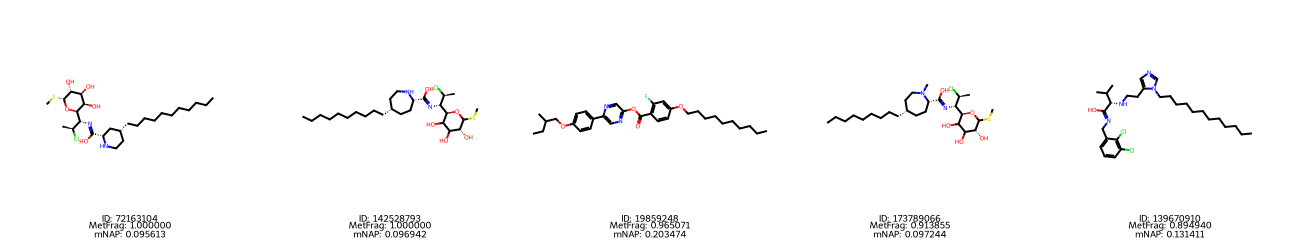


--- Node 88874: mNAP re-ranked Top 5 ---


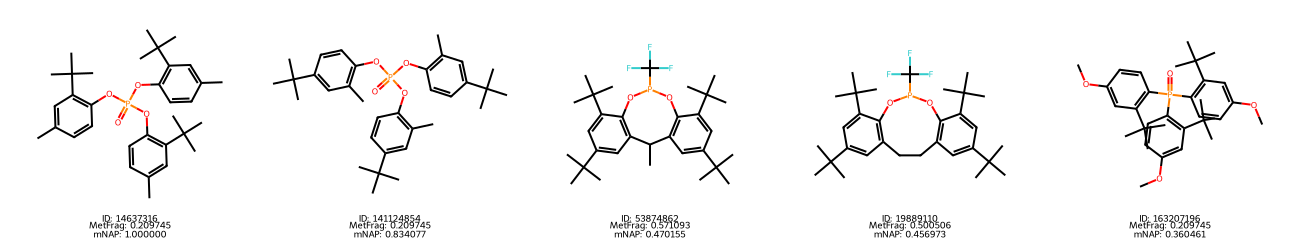

In [27]:
# =========================================================
# Optional structure visualization for one target node
# =========================================================

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd


def draw_comparison_panels(result_df, target_scan, top_n=10):
    """
    Display the top candidate structures before and after mNAP re-ranking.

    The mNAP panel uses the node-wise normalized mNAP score, for which the
    highest-scoring candidate within each spectral node has a value of 1.
    """
    df_node = result_df[
        result_df["cluster index"] == int(target_scan)
    ].copy()

    df_node = df_node[
        ~df_node["Identifier"].astype(str).str.startswith("Seed_")
    ].copy()

    if df_node.empty:
        print(f"No candidate structures were found for node {target_scan}.")
        return

    def generate_grid(df, sort_col, title_prefix):
        if sort_col not in df.columns:
            print(f"Required ranking column is missing: {sort_col}")
            return None

        top_df = df.sort_values(
            by=sort_col, ascending=False
        ).head(top_n)

        mols = []
        legends = []

        for _, row in top_df.iterrows():
            inchi = str(row.get("InChI", "")).strip()

            if not inchi.startswith("InChI="):
                continue

            mol = Chem.MolFromInchi(inchi)

            if mol is None:
                continue

            mols.append(mol)

            identifier = row.get("Identifier", "")
            metfrag_score = row.get("Score", 0)
            mnap_score = row.get("mNAP_score_norm", 0)

            legends.append(
                f"ID: {identifier}\n"
                f"MetFrag: {metfrag_score:.6f}\n"
                f"mNAP: {mnap_score:.6f}"
            )

        print(
            f"\n--- Node {target_scan}: {title_prefix} Top {top_n} ---"
        )

        if len(mols) == 0:
            print(
                f"No valid InChI structure was available among the Top {top_n} candidates."
            )
            return None

        return Draw.MolsToGridImage(
            mols,
            molsPerRow=5,
            subImgSize=(260, 250),
            legends=legends
        )

    img_metfrag = generate_grid(
        df_node, "Score", "Original MetFrag"
    )
    if img_metfrag is not None:
        display(img_metfrag)

    img_mnap = generate_grid(
        df_node, "mNAP_score_norm", "mNAP re-ranked"
    )
    if img_mnap is not None:
        display(img_mnap)


draw_comparison_panels(result_tab, target_node, top_n=5)



--- Node 88874: Original MetFrag Top 5 ---
SVG saved to: figures\MetFrag_node_88874_top5.svg
CairoSVG is not installed. The SVG vector figure has been saved successfully.


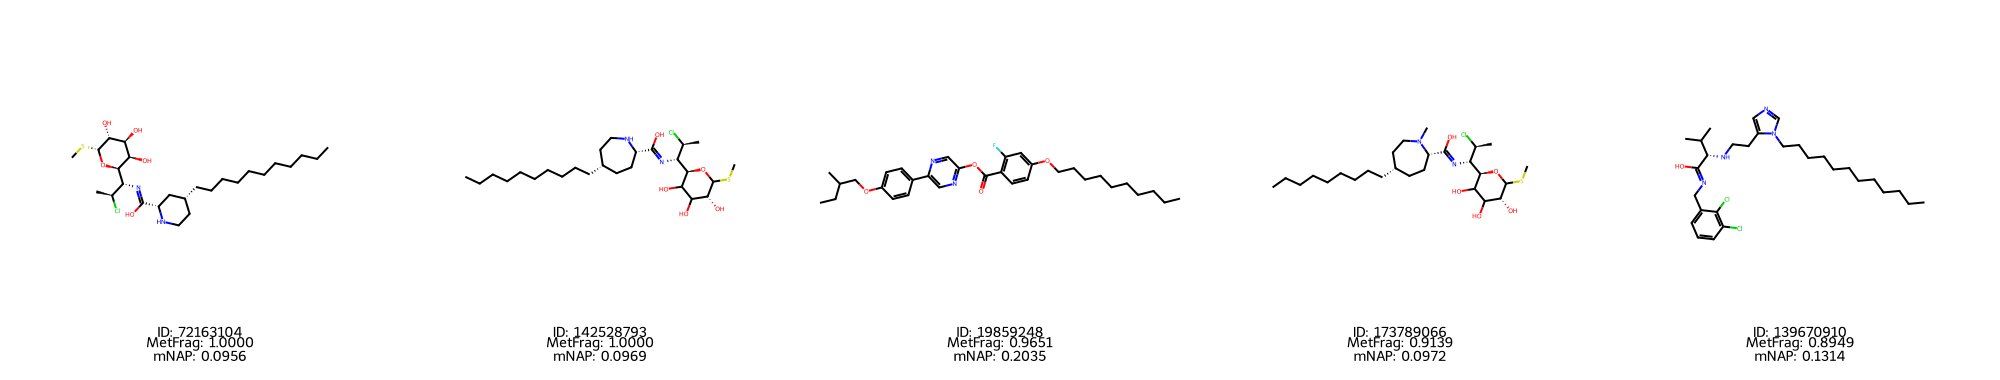


--- Node 88874: mNAP re-ranked Top 5 ---
SVG saved to: figures\mNAP_node_88874_top5.svg
CairoSVG is not installed. The SVG vector figure has been saved successfully.


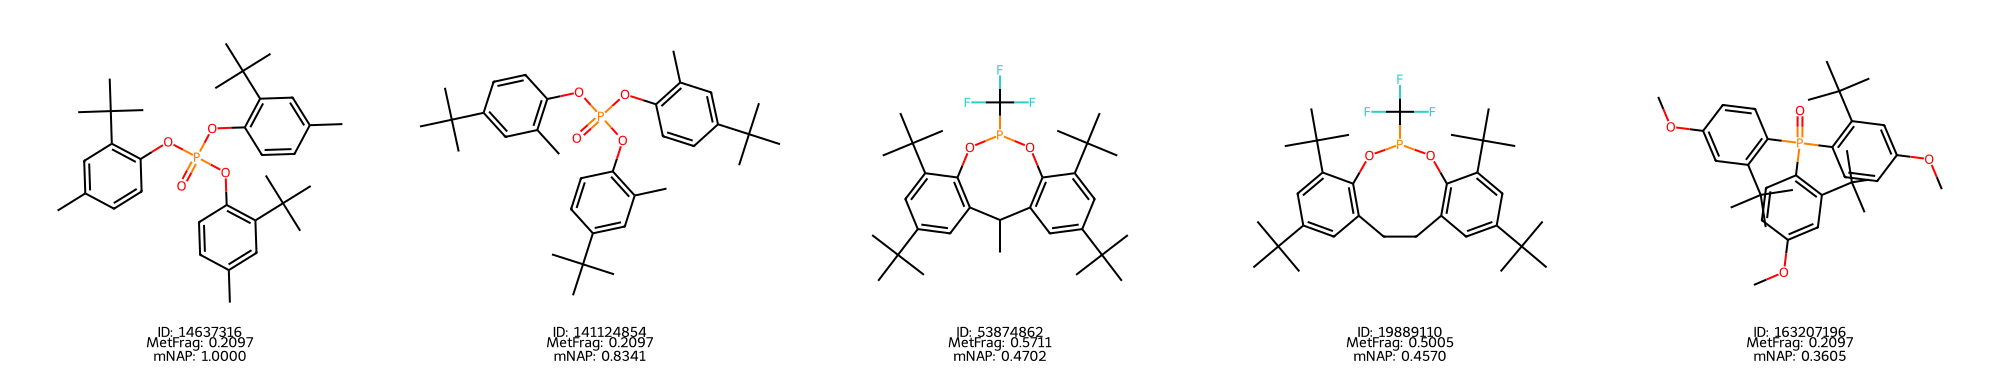

In [28]:
# =========================================================
# Optional structure visualization for one target node
# Export publication-quality SVG and PDF figures
# =========================================================

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, display
import pandas as pd
import os


def draw_comparison_panels(
    result_df,
    target_scan,
    top_n=10,
    output_dir="figures"
):
    """
    Display and export the top candidate structures before and after mNAP
    re-ranking.

    The mNAP panel uses the node-wise normalized mNAP score, for which the
    highest-scoring candidate within each spectral node has a value of 1.

    Figures are exported as vector SVG files. PDF files are also generated
    when CairoSVG is available.
    """

    os.makedirs(output_dir, exist_ok=True)

    df_node = result_df[
        result_df["cluster index"] == int(target_scan)
    ].copy()

    df_node = df_node[
        ~df_node["Identifier"].astype(str).str.startswith("Seed_")
    ].copy()

    if df_node.empty:
        print(f"No candidate structures were found for node {target_scan}.")
        return

    def generate_grid(df, sort_col, title_prefix, file_prefix):

        if sort_col not in df.columns:
            print(f"Required ranking column is missing: {sort_col}")
            return None

        top_df = (
            df.sort_values(by=sort_col, ascending=False)
            .head(top_n)
            .copy()
        )

        mols = []
        legends = []

        for _, row in top_df.iterrows():

            inchi = str(row.get("InChI", "")).strip()

            if not inchi.startswith("InChI="):
                continue

            mol = Chem.MolFromInchi(inchi)

            if mol is None:
                continue

            mols.append(mol)

            identifier = row.get("Identifier", "")
            metfrag_score = row.get("Score", 0)
            mnap_score = row.get("mNAP_score_norm", 0)

            legends.append(
                f"ID: {identifier}\n"
                f"MetFrag: {metfrag_score:.4f}\n"
                f"mNAP: {mnap_score:.4f}"
            )

        print(
            f"\n--- Node {target_scan}: "
            f"{title_prefix} Top {top_n} ---"
        )

        if len(mols) == 0:
            print(
                f"No valid InChI structure was available among "
                f"the Top {top_n} candidates."
            )
            return None

        # Generate a vector SVG grid
        svg = Draw.MolsToGridImage(
            mols,
            molsPerRow=5,
            subImgSize=(400, 380),
            legends=legends,
            useSVG=True
        )

        # RDKit versions may return either an SVG string or an SVG object
        svg_text = svg.data if hasattr(svg, "data") else str(svg)

        svg_path = os.path.join(
            output_dir,
            f"{file_prefix}_node_{target_scan}_top{top_n}.svg"
        )

        with open(svg_path, "w", encoding="utf-8") as f:
            f.write(svg_text)

        print(f"SVG saved to: {svg_path}")

        # Convert SVG to PDF when CairoSVG is available
        pdf_path = os.path.join(
            output_dir,
            f"{file_prefix}_node_{target_scan}_top{top_n}.pdf"
        )

        try:
            import cairosvg

            cairosvg.svg2pdf(
                bytestring=svg_text.encode("utf-8"),
                write_to=pdf_path
            )

            print(f"PDF saved to: {pdf_path}")

        except ImportError:
            print(
                "CairoSVG is not installed. "
                "The SVG vector figure has been saved successfully."
            )

        # Display the vector figure in the notebook
        display(SVG(svg_text))

        return top_df


    # Original MetFrag ranking
    metfrag_top = generate_grid(
        df_node,
        sort_col="Score",
        title_prefix="Original MetFrag",
        file_prefix="MetFrag"
    )

    # mNAP re-ranked candidates
    mnap_top = generate_grid(
        df_node,
        sort_col="mNAP_score_norm",
        title_prefix="mNAP re-ranked",
        file_prefix="mNAP"
    )

    return metfrag_top, mnap_top


# Example: visualize and export the top five candidates for the selected node
metfrag_top, mnap_top = draw_comparison_panels(
    result_tab,
    target_node,
    top_n=5,
    output_dir="figures"
)